<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
## I am going to take Car_crash dataset to perform analysis.

In [8]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
## fetching the data from Seaborn library
df=sns.load_dataset('taxis')

In [10]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


## Data description

1-pickup: Timestamp when the trip began

2-Dropoff: Timestamp when the trip ended

3-Passengers : Number of passengers for the trip

4-distance: Distance traveled, often in miles or kilometers

5-Fare : Base fare charged for the trip

6-trip : Duration of the trip in seconds

7-tolls: toll given for the trip

8-total: Total amount charged for the trip

9-color: Color of the taxi

10-payment: Payment method used for the trip

11-pickup_zone: Geographic area where the trip started

12-dropoff_zone: Geographic area where the trip ended

13-pickup_borough: Borough where the trip started

14-dropoff_borough: Borough where the trip end.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [21]:
import pandas.api.types as ptypes

for col in df.columns:
  # Check if the column is numeric or datetime
  if ptypes.is_numeric_dtype(df[col]) or ptypes.is_datetime64_any_dtype(df[col]):
    print(f"{col}")
    print(f"Min : {df[col].min()} ")
    print(f"Max : {df[col].max()}")
    print(f"Mean : {df[col].mean()}")
    print(f"Median : {df[col].median()}")
    print("-"*50)
  # Otherwise, it's likely an object (string) or categorical type
  else:
    print(f"{col}={df[col].unique()}")
    print("-"*50)

pickup
Min : 2019-02-28 23:29:03 
Max : 2019-03-31 23:43:45
Mean : 2019-03-16 08:31:28.514223616
Median : 2019-03-15 21:46:58
--------------------------------------------------
dropoff
Min : 2019-02-28 23:32:35 
Max : 2019-04-01 00:13:58
Mean : 2019-03-16 08:45:49.491217408
Median : 2019-03-15 22:06:44
--------------------------------------------------
passengers
Min : 0 
Max : 6
Mean : 1.539250738380227
Median : 1.0
--------------------------------------------------
distance
Min : 0.0 
Max : 36.7
Mean : 3.024616819524328
Median : 1.64
--------------------------------------------------
fare
Min : 1.0 
Max : 150.0
Mean : 13.091072594434944
Median : 9.5
--------------------------------------------------
tip
Min : 0.0 
Max : 33.2
Mean : 1.9792196486864604
Median : 1.7
--------------------------------------------------
tolls
Min : 0.0 
Max : 24.02
Mean : 0.3252728120628012
Median : 0.0
--------------------------------------------------
total
Min : 1.3 
Max : 174.82
Mean : 18.51779418622726

In [22]:
## getting information about shape
df.shape

(6433, 14)

In [23]:
df.shape[0]

6433

In [24]:
df.shape[1]

14

### EDA

In [25]:
## Getting an idea about datatype
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


### All the columns are of correct data type.

In [26]:
## getting an idea about duplicate value
df.duplicated().sum()

np.int64(0)

In [27]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
6428,False
6429,False
6430,False
6431,False


## As the value is 0 means there is no duplicate row.

In [28]:
## Finding missing values
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [29]:
## analysis says
 There are missing values in payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough

IndentationError: unexpected indent (911650234.py, line 2)

In [30]:
## Filling missing values
df['payment']=df['payment'].fillna(df['payment'].mode(),)

In [31]:
## filling missing values in column pickup_zone
df['pickup_zone']=df['pickup_zone'].fillna('no_pickup_zone')

In [32]:
df['dropoff_zone']=df['dropoff_zone'].fillna('no_dropoff_zone')
df['pickup_borough']=df['pickup_borough'].fillna('no_pickup_borough')
df['dropoff_borough']=df['dropoff_borough'].fillna('no_dropoff_borough')

In [33]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
## So there is no null values in the dateset.

##In this dataset the target variable is Total_amount..which is numerical in nature.

In [34]:
## To describe the data
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
## in above data
 for passenger column mean is more then 50% so data is right skewed for passenger.
 for fare column mean is more then 50% so data is right skewed for passenger.
 for tip column mean is more then 50% so data is right skewed for passenger.
 for tolls column mean is more then 50% so data is right skewed for passenger.
 for passenger column mean is more then 50% so data is right skewed for passenger.


In [35]:
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [36]:
df['color'].unique()

array(['yellow', 'green'], dtype=object)

In [37]:
df['color']=df['color'].replace('yellow','y')

In [38]:
df['color']=df['color'].replace('green','g')

In [39]:
df['payment'].unique()

array(['credit card', 'cash', nan], dtype=object)

In [40]:
df['payment']=df['payment'].replace('cash','c')
df['payment']=df['payment'].replace('credit','cr')
df['payment']=df['payment'].replace('no','n')

In [41]:
df.groupby('distance')['tip'].mean().reset_index().sort_values(by='tip',ascending=False)

,distance,tip
1071,26.92,23.19
792,10.36,20.56
1067,24.63,17.86
869,12.60,17.10
959,16.77,16.39
...,...,...
862,12.40,0.00
751,9.66,0.00
765,9.96,0.00
767,9.98,0.00


In [42]:
df.groupby('distance')['total'].mean().reset_index().sort_values(by='total',ascending=False)

,distance,total
1078,36.70,174.820000
1075,33.46,169.700000
1076,33.76,144.300000
1070,26.35,136.560000
792,10.36,123.360000
...,...,...
5,0.07,3.966667
16,0.19,3.800000
3,0.03,3.800000
4,0.04,3.800000


In [43]:
df.groupby('distance')['fare'].mean().reset_index().sort_values(by='fare',ascending=False)

,distance,fare
1078,36.70,150.0
1075,33.46,150.0
1076,33.76,143.5
1070,26.35,130.0
792,10.36,100.0
...,...,...
3,0.03,2.5
5,0.07,2.5
2,0.02,2.5
6,0.08,2.5


In [44]:
df.groupby('fare')['tip'].mean().reset_index().sort_values(by='tip',ascending=False)

,fare,tip
216,120.00,33.20
204,75.50,23.19
200,69.06,20.80
215,103.00,20.65
214,100.00,20.56
...,...,...
206,79.50,0.00
212,93.50,0.00
217,130.00,0.00
218,143.50,0.00


## more the fare ,more the tip is paid by customers.

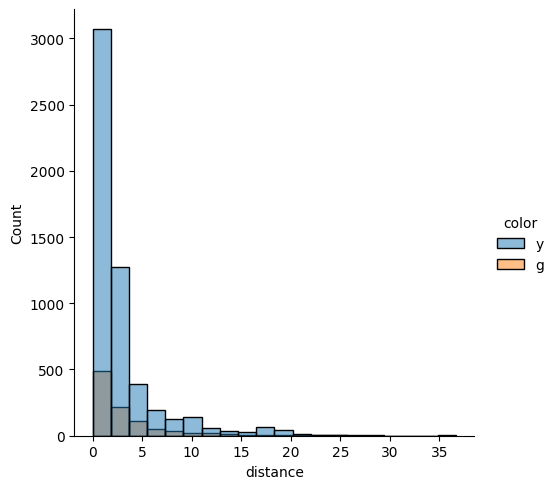

In [45]:
sns.displot(df,x='distance',hue='color',bins=20)

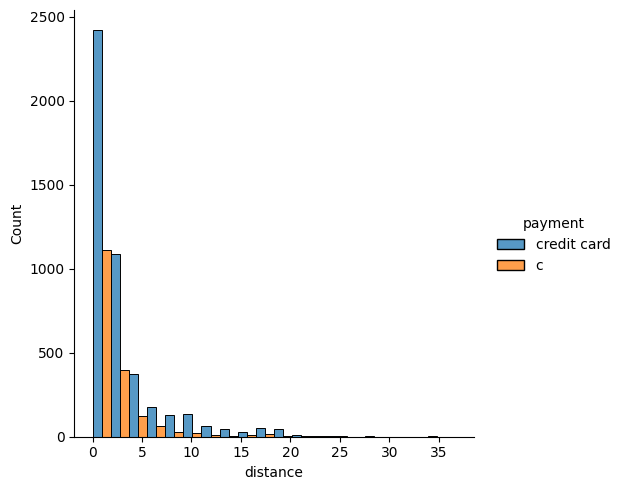

In [46]:
sns.displot(df,x='distance',hue='payment',multiple="dodge",bins=20) ##multiple make side by side

## most of the people paid rent through credit card.

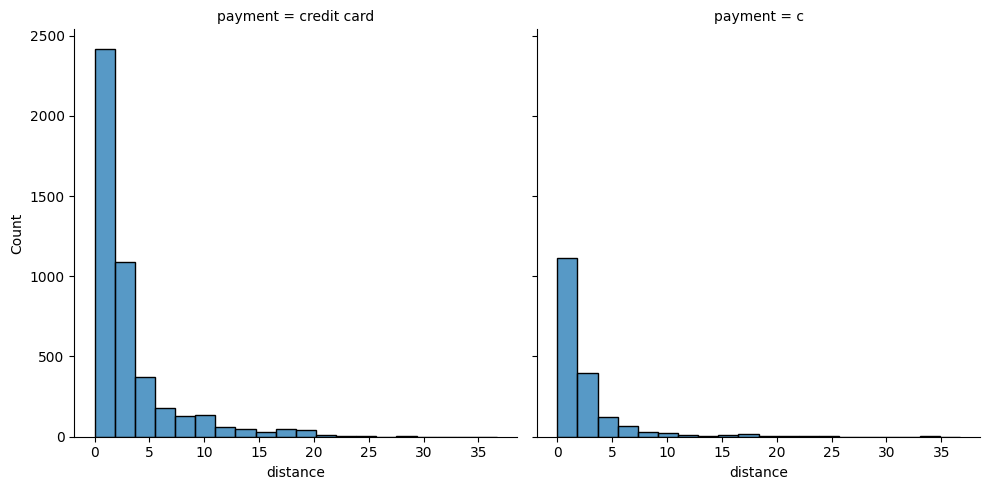

In [47]:
sns.displot(df,x='distance',col='payment',bins=20)###col make subplot

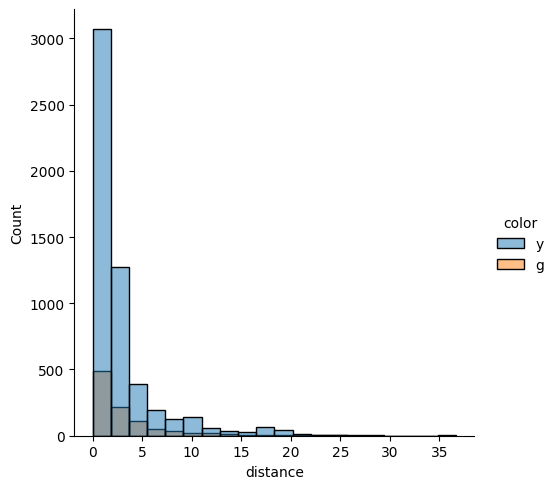

In [48]:
sns.displot(df,x='distance',bins=20,hue='color')

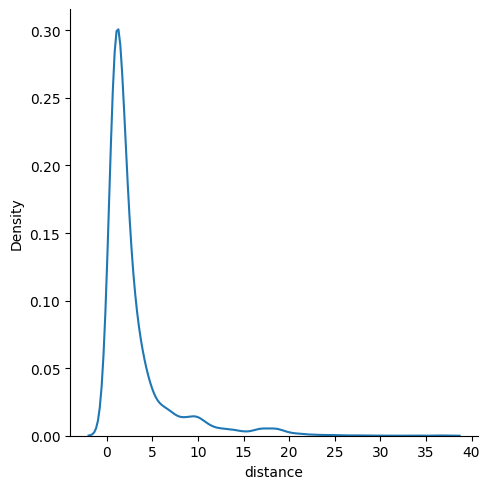

In [49]:
sns.displot(df,x='distance',kind="kde")## distribution curve with displot

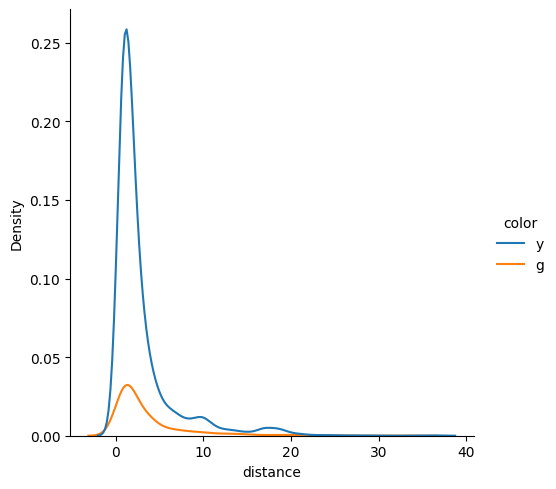

In [50]:
sns.displot(df,x='distance',hue='color',kind="kde")

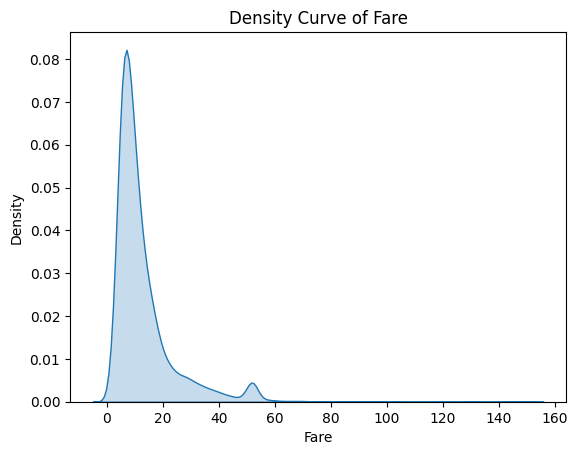

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(df['fare'], fill=True)
plt.title('Density Curve of Fare')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

##most of the people paid 10-15$ as a fare.

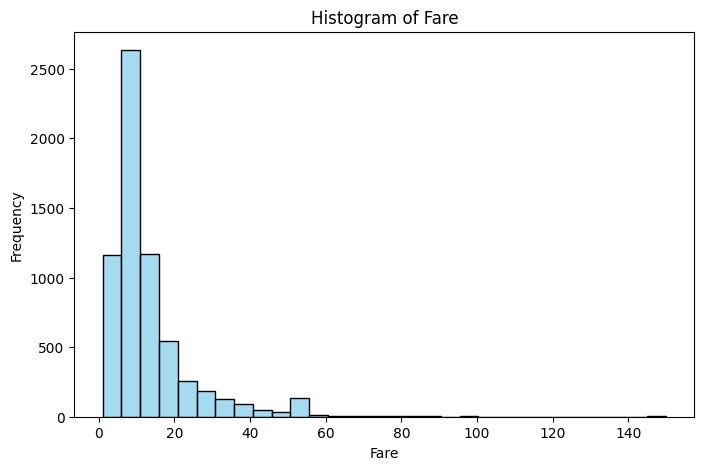

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(df['fare'], bins=30, kde=False, color='skyblue')
plt.title('Histogram of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

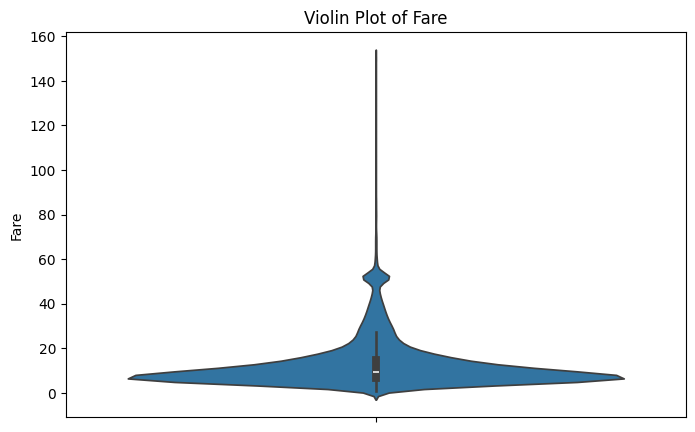

In [53]:
plt.figure(figsize=(8, 5))
sns.violinplot(y=df['fare'])
plt.title('Violin Plot of Fare')
plt.ylabel('Fare')
plt.show()

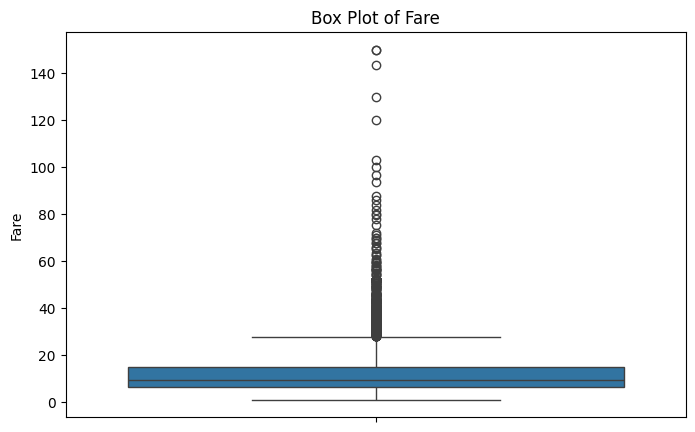

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')
plt.show()

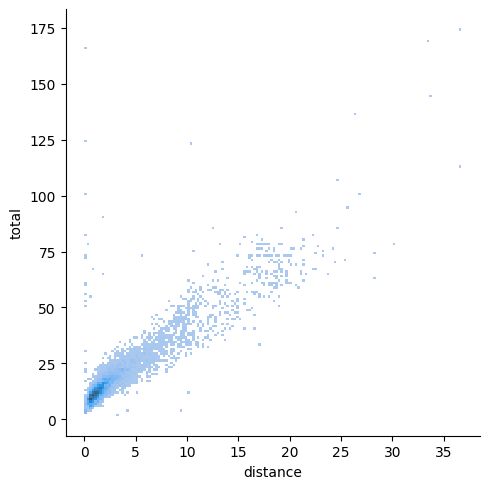

In [55]:
sns.displot(df, x="distance", y="total")

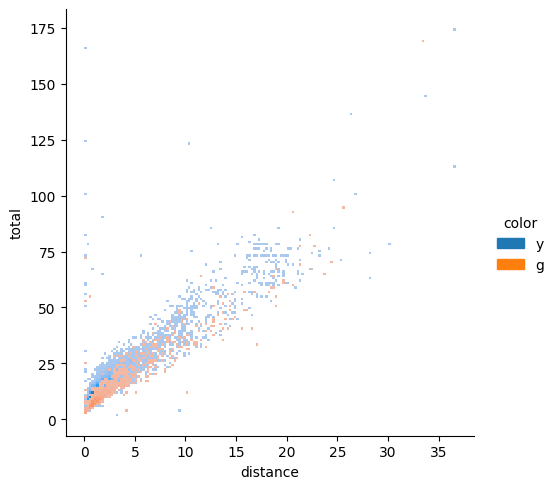

In [56]:
sns.displot(df, x="distance", y="total", hue='color')

## As the distance increases total money paid increases.